<a href="https://colab.research.google.com/github/ame-no-uzume6/telecom-x/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X - Análisis de Evasión de Clientes**

##**Extracción de datos**

In [44]:
import pandas as pd

In [45]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

In [46]:
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [47]:
nested_columns = ['customer', 'phone', 'internet', 'account']
nested_columns

['customer', 'phone', 'internet', 'account']

In [48]:
for col in nested_columns:
    normalized_df = pd.json_normalize(df[col])
    df = pd.concat([df.drop(col, axis=1), normalized_df], axis=1)

In [49]:
pd.set_option('display.max_columns',None)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##**Transformación**

In [50]:
df.shape

(7267, 21)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [52]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [53]:
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [54]:
for col in df.columns:
    print(f'Unique values for {col}:')
    print(df[col].unique())
    print('-' * 30)

Unique values for customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Unique values for Churn:
['No' 'Yes' '']
------------------------------
Unique values for gender:
['Female' 'Male']
------------------------------
Unique values for SeniorCitizen:
[0 1]
------------------------------
Unique values for Partner:
['Yes' 'No']
------------------------------
Unique values for Dependents:
['Yes' 'No']
------------------------------
Unique values for tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
------------------------------
Unique values for PhoneService:
['Yes' 'No']
------------------------------
Unique values for MultipleLines:
['No' 'Yes' 'No phone service']
------------------------------
Unique values for InternetService:
['DS

In [55]:
df = df.drop(columns=['customerID'])
display(df.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [56]:
(df['Churn'] == '').sum()

np.int64(224)

In [57]:
df = df[df['Churn'] != '']
(df['Churn'] == '').sum()

np.int64(0)

In [58]:
for col in df.columns:
  df[col] = df[col].replace({'Yes': 1, 'No': 0})

df.head()

/tmp/ipykernel_398/3937358821.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [59]:
df = df.rename(columns={'Charges.Monthly': 'MonthlyCharges', 'Charges.Total': 'TotalCharges'})
display(df.columns)

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [60]:
df.query('MonthlyCharges==0')

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


In [61]:
df.query('tenure>0 & TotalCharges==0')

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


In [62]:
df.query('PhoneService == 0 & InternetService==0')

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


In [63]:
nombre_columnas = {
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Tercera Edad',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses Antiguedad',
    'PhoneService': 'Servicio Telefonico',
    'MultipleLines': 'Lineas Multiples',
    'InternetService': 'Servicio Internet',
    'OnlineSecurity': 'Seguridad Online',
    'OnlineBackup': 'Respaldo Online',
    'DeviceProtection': 'Proteccion Dispositivo',
    'TechSupport': 'Soporte Tecnico Rapido',
    'StreamingTV': 'Streaming TV',
    'StreamingMovies': 'Streaming Peliculas',
    'Contract': 'Tipo Contrato',
    'PaperlessBilling': 'Facturacion Online',
    'PaymentMethod': 'Metodo Pago',
    'MonthlyCharges': 'Cargos Mensuales',
    'TotalCharges': 'Cargos Totales'
}

df = df.rename(columns=nombre_columnas)
df.columns

Index(['Evasion', 'Genero', 'Tercera Edad', 'Pareja', 'Dependientes',
       'Meses Antiguedad', 'Servicio Telefonico', 'Lineas Multiples',
       'Servicio Internet', 'Seguridad Online', 'Respaldo Online',
       'Proteccion Dispositivo', 'Soporte Tecnico Rapido', 'Streaming TV',
       'Streaming Peliculas', 'Tipo Contrato', 'Facturacion Online',
       'Metodo Pago', 'Cargos Mensuales', 'Cargos Totales'],
      dtype='object')

In [64]:
traducciones = {
    'Female': 'Femenino',
    'Male': 'Masculino',
    'Fiber optic': 'Fibra óptica',
    'No phone service': 'Sin servicio telefónico',
    'No internet service': 'Sin servicio de internet',
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años',
    'Mailed check': 'Cheque por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automática)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
}

df = df.replace(traducciones)
df['Servicio Internet'] = df['Servicio Internet'].replace({0: 'Sin servicio de internet'})

In [65]:
df['Cargos Diarios'] = df['Cargos Mensuales'] / 30
df.head()

,Evasion,Genero,Tercera Edad,Pareja,Dependientes,Meses Antiguedad,Servicio Telefonico,Lineas Multiples,Servicio Internet,Seguridad Online,Respaldo Online,Proteccion Dispositivo,Soporte Tecnico Rapido,Streaming TV,Streaming Peliculas,Tipo Contrato,Facturacion Online,Metodo Pago,Cargos Mensuales,Cargos Totales,Cargos Diarios
0,0,Femenino,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.186667
1,0,Masculino,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.40,1.996667
2,1,Masculino,0,0,0,4,1,0,Fibra óptica,0,0,1,0,0,0,Mes a mes,1,Cheque electrónico,73.9,280.85,2.463333
3,1,Masculino,1,1,0,13,1,0,Fibra óptica,0,1,1,0,1,1,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.266667
4,1,Femenino,1,1,0,3,1,0,Fibra óptica,0,0,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.796667


In [66]:
for col in df.columns:
    print(f'Unique values for {col}:')
    print(df[col].unique())
    print('-' * 30)

Unique values for Evasion:
[0 1]
------------------------------
Unique values for Genero:
['Femenino' 'Masculino']
------------------------------
Unique values for Tercera Edad:
[0 1]
------------------------------
Unique values for Pareja:
[1 0]
------------------------------
Unique values for Dependientes:
[1 0]
------------------------------
Unique values for Meses Antiguedad:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
------------------------------
Unique values for Servicio Telefonico:
[1 0]
------------------------------
Unique values for Lineas Multiples:
[0 1 'Sin servicio telefónico']
------------------------------
Unique values for Servicio Internet:
['DSL' 'Fibra óptica' 'Sin servicio de internet']
------------------------------
Unique values for Seguridad Online:
[0 1 'Sin servicio de internet']


##**Carga y Análisis**

###Estadísticas descriptivas

In [67]:
df.describe().round(2)

,Evasion,Tercera Edad,Pareja,Dependientes,Meses Antiguedad,Servicio Telefonico,Facturacion Online,Cargos Mensuales,Cargos Totales,Cargos Diarios
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00
mean,0.27,0.16,0.48,0.30,32.37,0.9,0.59,64.76,2279.73,2.16
std,0.44,0.37,0.50,0.46,24.56,0.3,0.49,30.09,2266.79,1.00
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,18.25,0.00,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,35.50,398.55,1.18
50%,0.00,0.00,0.00,0.00,29.00,1.0,1.00,70.35,1394.55,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,89.85,3786.60,2.99
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,118.75,8684.80,3.96


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

###**Distribución de evasión**

In [69]:
distribucion_evasion = (df['Evasion'].value_counts(normalize=True) * 100).round(2)

In [70]:
distribucion_evasion= distribucion_evasion.reset_index()
distribucion_evasion.columns = ['Evasion', 'Proporcion']
distribucion_evasion['Evasion'] = distribucion_evasion['Evasion'].map({0: 'No', 1: 'Sí'})
fig = px.pie(distribucion_evasion, values='Proporcion', names='Evasion', title='Distribución de Evasión (%)')
fig.show()

####**Variables Categóricas**

In [71]:
df_evasion = df.query('Evasion == 1').copy()
df_evasion.head()

,Evasion,Genero,Tercera Edad,Pareja,Dependientes,Meses Antiguedad,Servicio Telefonico,Lineas Multiples,Servicio Internet,Seguridad Online,Respaldo Online,Proteccion Dispositivo,Soporte Tecnico Rapido,Streaming TV,Streaming Peliculas,Tipo Contrato,Facturacion Online,Metodo Pago,Cargos Mensuales,Cargos Totales,Cargos Diarios
2,1,Masculino,0,0,0,4,1,0,Fibra óptica,0,0,1,0,0,0,Mes a mes,1,Cheque electrónico,73.9,280.85,2.463333
3,1,Masculino,1,1,0,13,1,0,Fibra óptica,0,1,1,0,1,1,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.266667
4,1,Femenino,1,1,0,3,1,0,Fibra óptica,0,0,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.796667
18,1,Masculino,1,0,0,45,1,0,DSL,1,0,1,0,0,1,Un año,0,Tarjeta de crédito (automática),62.7,2791.50,2.090000
19,1,Masculino,1,0,0,1,0,Sin servicio telefónico,DSL,0,0,0,0,0,0,Mes a mes,1,Cheque electrónico,25.1,25.10,0.836667


#####Demográficas

In [72]:
df_genero = df_evasion['Genero'].value_counts().reset_index()
df_genero.columns = ['Genero', 'Cantidad']
df_tercera_edad = df_evasion['Tercera Edad'].value_counts().reset_index()
df_tercera_edad.columns = ['Tercera Edad', 'Cantidad']
df_pareja = df_evasion['Pareja'].value_counts().reset_index()
df_pareja.columns = ['Pareja', 'Cantidad']
df_dependientes = df_evasion['Dependientes'].value_counts().reset_index()
df_dependientes.columns = ['Dependientes', 'Cantidad']

In [73]:
import matplotlib.pyplot as plt

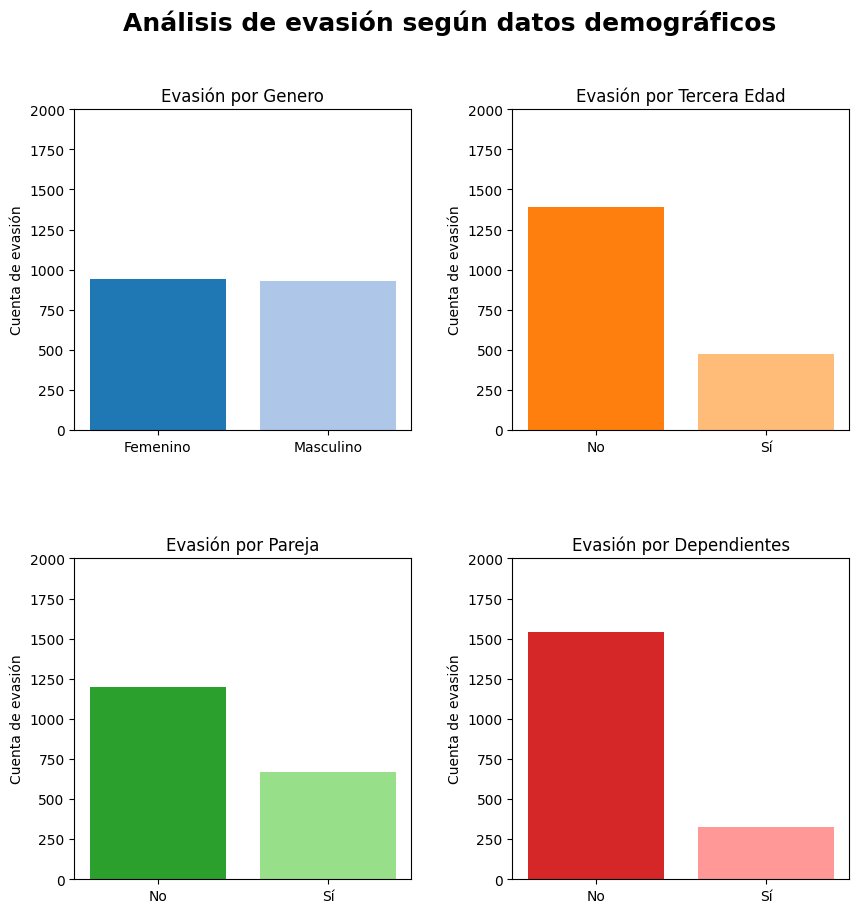

In [74]:
import matplotlib.pyplot as plt

palettes_demo = [
    ['#aec7e8', '#1f77b4'], # Azules
    ['#ffbb78', '#ff7f0e'], # Naranjas
    ['#98df8a', '#2ca02c'], # Verdes
    ['#ff9896', '#d62728']  # Rojos
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Análisis de evasión según datos demográficos', fontsize=18, fontweight='bold')
fig.subplots_adjust(hspace=0.4, wspace=0.3)

def get_colors(data, palette):
    max_val = data.max()
    return [palette[1] if v == max_val else palette[0] for v in data]

demo_data = [
    (df_genero, 'Genero'),
    (df_tercera_edad, 'Tercera Edad'),
    (df_pareja, 'Pareja'),
    (df_dependientes, 'Dependientes')
]

replace_map = {0: 'No', 1: 'Sí'}
ax_flat = axes.flatten()

for i, (df_plot, col_name) in enumerate(demo_data):
    x_labels = df_plot[col_name].replace(replace_map)
    ax_flat[i].bar(x_labels, df_plot['Cantidad'], color=get_colors(df_plot['Cantidad'], palettes_demo[i]))
    ax_flat[i].set_title(f'Evasión por {col_name}')
    ax_flat[i].set_ylabel('Cuenta de evasión')
    ax_flat[i].set_ylim(0, 2000)

plt.show()

#####Servicios base y términos de contrato

In [75]:
df_servicio_telefonico = df_evasion['Servicio Telefonico'].value_counts().reset_index()
df_servicio_telefonico.columns = ['Servicio Telefonico', 'Cantidad']

df_servicio_internet = df_evasion['Servicio Internet'].value_counts().reset_index()
df_servicio_internet.columns = ['Servicio Internet', 'Cantidad']

df_tipo_contrato = df_evasion['Tipo Contrato'].value_counts().reset_index()
df_tipo_contrato.columns = ['Tipo Contrato', 'Cantidad']

df_facturacion_online = df_evasion['Facturacion Online'].value_counts().reset_index()
df_facturacion_online.columns = ['Facturacion Online', 'Cantidad']

df_metodo_pago = df_evasion['Metodo Pago'].value_counts().reset_index()
df_metodo_pago.columns = ['Metodo Pago', 'Cantidad']

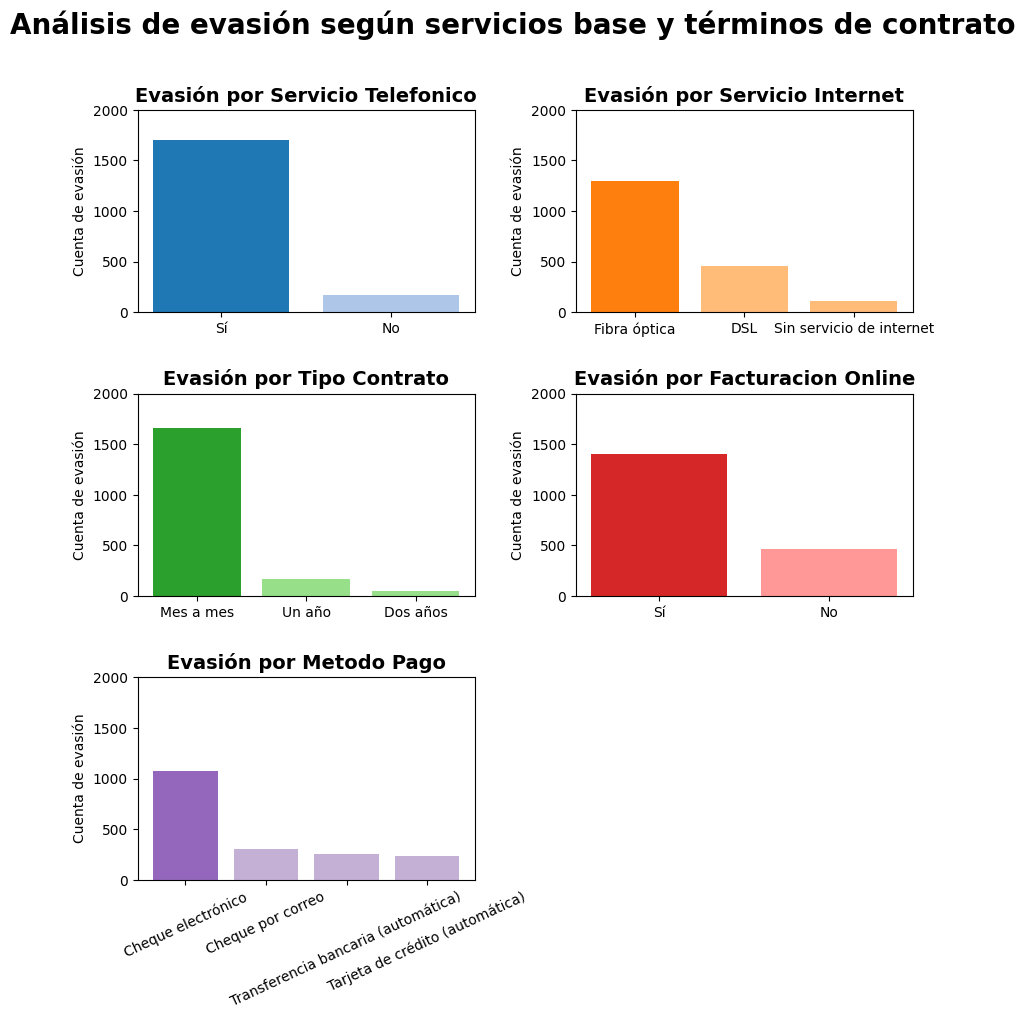

In [76]:
palettes_servicios_base = [
    ['#aec7e8', '#1f77b4'], # Azules
    ['#ffbb78', '#ff7f0e'], # Naranjas
    ['#98df8a', '#2ca02c'], # Verdes
    ['#ff9896', '#d62728'], # Rojos
    ['#c5b0d5', '#9467bd']  # Púrpuras
]

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
fig.suptitle('Análisis de evasión según servicios base y términos de contrato', fontsize=20, fontweight='bold')
fig.subplots_adjust(hspace=0.4, wspace=0.3)

def get_dynamic_colors(data, palette):
    max_val = data.max()
    return [palette[1] if v == max_val else palette[0] for v in data]

base_services_data = [
    (df_servicio_telefonico, 'Servicio Telefonico'),
    (df_servicio_internet, 'Servicio Internet'),
    (df_tipo_contrato, 'Tipo Contrato'),
    (df_facturacion_online, 'Facturacion Online'),
    (df_metodo_pago, 'Metodo Pago')
]

replace_map = {0: 'No', 1: 'Sí'}
ax_flat = axes.flatten()

for i, (df_plot, col_name) in enumerate(base_services_data):
    x_labels = df_plot[col_name].astype(str).replace({'0': 'No', '1': 'Sí', '0.0': 'No', '1.0': 'Sí'})
    ax_flat[i].bar(x_labels, df_plot['Cantidad'], color=get_dynamic_colors(df_plot['Cantidad'], palettes_servicios_base[i]))
    ax_flat[i].set_title(f'Evasión por {col_name}', fontsize=14, fontweight='bold')
    ax_flat[i].set_ylabel('Cuenta de evasión')
    ax_flat[i].set_ylim(0, 2000)
    if col_name == 'Metodo Pago':
        ax_flat[i].tick_params(axis='x', rotation=25)

fig.delaxes(ax_flat[-1])
plt.show()

#####Servicios asociados

In [77]:
df_lineas_multiples = df_evasion['Lineas Multiples'].value_counts().reset_index()
df_lineas_multiples.columns = ['Lineas Multiples', 'Cantidad']

df_seguridad_online = df_evasion['Seguridad Online'].value_counts().reset_index()
df_seguridad_online.columns = ['Seguridad Online', 'Cantidad']

df_respaldo_online = df_evasion['Respaldo Online'].value_counts().reset_index()
df_respaldo_online.columns = ['Respaldo Online', 'Cantidad']

df_proteccion_dispositivo = df_evasion['Proteccion Dispositivo'].value_counts().reset_index()
df_proteccion_dispositivo.columns = ['Proteccion Dispositivo', 'Cantidad']

df_soporte_tecnico = df_evasion['Soporte Tecnico Rapido'].value_counts().reset_index()
df_soporte_tecnico.columns = ['Soporte Tecnico Rapido', 'Cantidad']

df_streaming_tv = df_evasion['Streaming TV'].value_counts().reset_index()
df_streaming_tv.columns = ['Streaming TV', 'Cantidad']

df_streaming_peliculas = df_evasion['Streaming Peliculas'].value_counts().reset_index()
df_streaming_peliculas.columns = ['Streaming Peliculas', 'Cantidad']

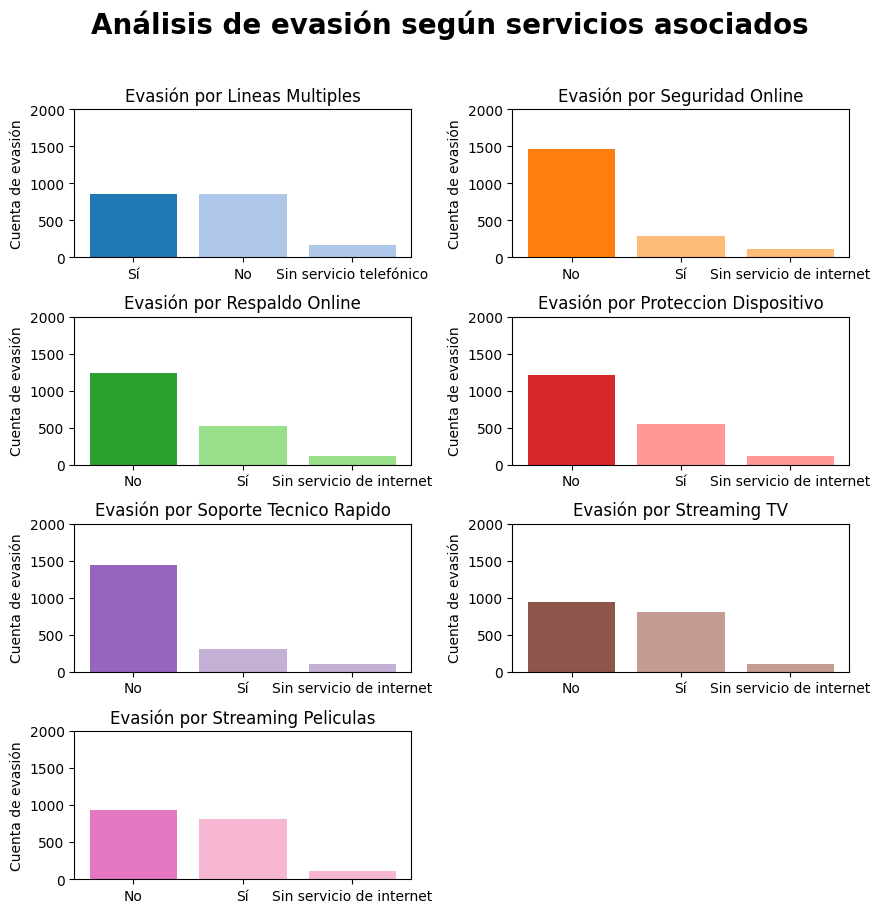

In [78]:
palettes_servicios = [
    ['#aec7e8', '#1f77b4'],
    ['#ffbb78', '#ff7f0e'],
    ['#98df8a', '#2ca02c'],
    ['#ff9896', '#d62728'],
    ['#c5b0d5', '#9467bd'],
    ['#c49c94', '#8c564b'],
    ['#f7b6d2', '#e377c2']
]

fig, axes = plt.subplots(4, 2, figsize=(10, 10))
fig.suptitle('Análisis de evasión según servicios asociados', fontsize=20, fontweight='bold')
fig.subplots_adjust(hspace=0.4, wspace=0.3)

def get_colors(data, palette):
    max_val = data.max()
    return [palette[1] if v == max_val else palette[0] for v in data]

services_data = [
    (df_lineas_multiples, 'Lineas Multiples'),
    (df_seguridad_online, 'Seguridad Online'),
    (df_respaldo_online, 'Respaldo Online'),
    (df_proteccion_dispositivo, 'Proteccion Dispositivo'),
    (df_soporte_tecnico, 'Soporte Tecnico Rapido'),
    (df_streaming_tv, 'Streaming TV'),
    (df_streaming_peliculas, 'Streaming Peliculas')
]

replace_map = {0: 'No', 1: 'Sí'}
ax_flat = axes.flatten()

for i, (df_plot, col_name) in enumerate(services_data):
    x_labels = df_plot[col_name].replace(replace_map)
    ax_flat[i].bar(x_labels, df_plot['Cantidad'], color=get_colors(df_plot['Cantidad'], palettes_servicios[i]))
    ax_flat[i].set_title(f'Evasión por {col_name}')
    ax_flat[i].set_ylabel('Cuenta de evasión')
    ax_flat[i].set_ylim(0, 2000)

fig.delaxes(ax_flat[-1])
plt.show()

####**Variables Numéricas**

#####Meses de Antiguedad

In [79]:
stats_antiguedad = df.groupby('Evasion')['Meses Antiguedad'].agg(['mean', 'median']).round(2)
stats_antiguedad = stats_antiguedad.reset_index()
stats_antiguedad.columns = ['Evasion', 'Promedio Antiguedad', 'Mediana Antiguedad']
display(stats_antiguedad)

,Evasion,Promedio Antiguedad,Mediana Antiguedad
0,0,37.57,38.0
1,1,17.98,10.0


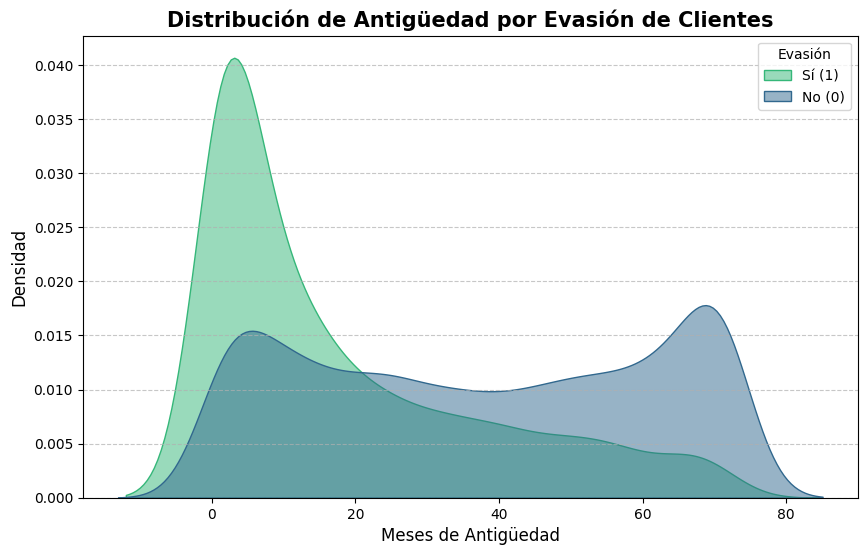

In [80]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Meses Antiguedad', hue='Evasion', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('Distribución de Antigüedad por Evasión de Clientes', fontsize=15, fontweight='bold')
plt.xlabel('Meses de Antigüedad', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(title='Evasión', labels=['Sí (1)', 'No (0)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [81]:
new_customers = df[df['Meses Antiguedad'] < 12]
veteran_customers = df[df['Meses Antiguedad'] >= 12]
churn_rate_new = (new_customers['Evasion'] == 1).mean() * 100
churn_rate_veteran = (veteran_customers['Evasion'] == 1).mean() * 100
print(f'Tasa de evasión en clientes nuevos (< 12 meses): {churn_rate_new:.2f}%')
print(f'Tasa de evasión en clientes veteranos (>= 12 meses): {churn_rate_veteran:.2f}%')

Tasa de evasión en clientes nuevos (< 12 meses): 48.28%
Tasa de evasión en clientes veteranos (>= 12 meses): 17.49%


#####Cargos

In [82]:
stats_cargos = df.groupby('Evasion')[['Cargos Diarios', 'Cargos Mensuales', 'Cargos Totales']].agg(['mean', 'median'])

stats_cargos = stats_cargos.style.format("{:.2f}") \
    .background_gradient(cmap='YlOrRd') \
    .set_caption("Estadísticas Descriptivas de Cargos por Evasión") \
    .set_table_styles([{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]}])

stats_cargos

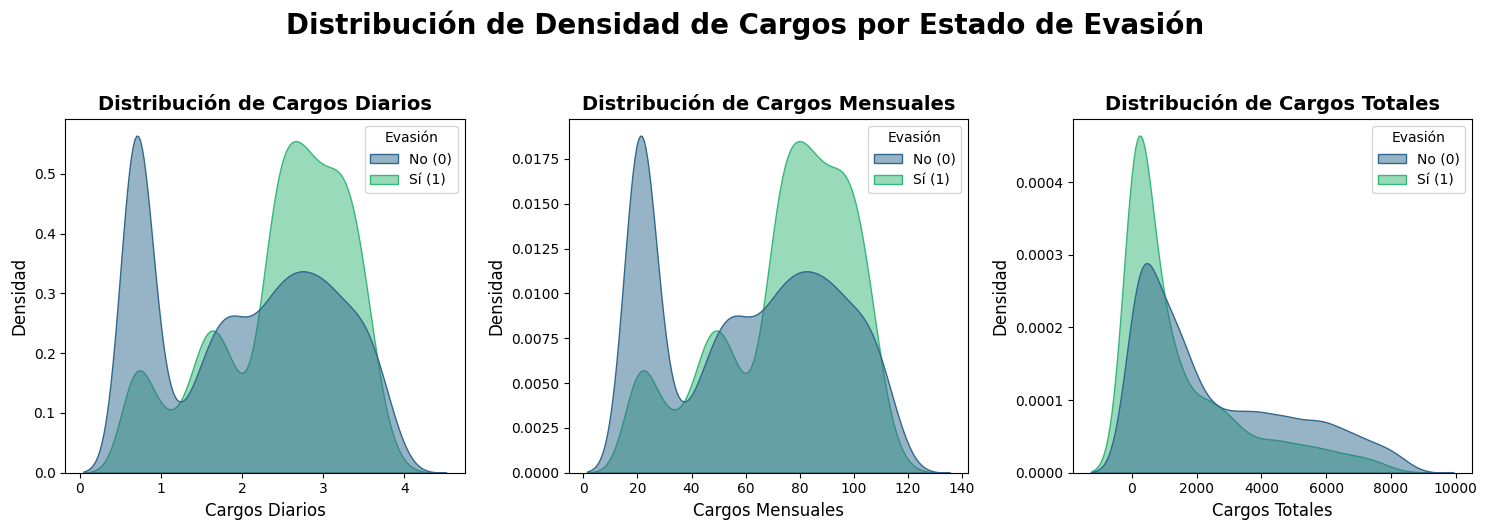

In [83]:
columnas_cargos = ['Cargos Diarios', 'Cargos Mensuales', 'Cargos Totales']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de Densidad de Cargos por Estado de Evasión', fontsize=20, fontweight='bold', y=1.05)

for i, col in enumerate(columnas_cargos):
    sns.kdeplot(
        data=df,
        x=col,
        hue='Evasion',
        fill=True,
        common_norm=False,
        palette='viridis',
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Densidad', fontsize=12)
    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Evasión')
        for text, label in zip(legend.get_texts(), ['No (0)', 'Sí (1)']):
            text.set_text(label)

plt.tight_layout()
plt.show()

### **Análisis de Correlación y Servicios Adicionales**

En esta sección, exploraremos cómo la diversificación de servicios (cantidad de productos contratados) influye en la fidelidad del cliente y visualizaremos la correlación entre las variables numéricas.

/tmp/ipykernel_398/2709967970.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




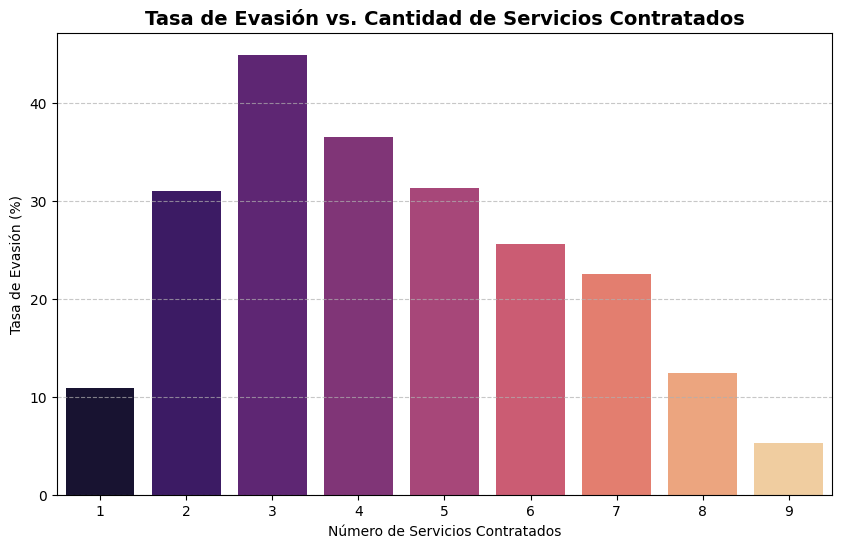

In [84]:
servicios = [
    'Servicio Telefonico','Servicio Internet', 'Lineas Multiples', 'Seguridad Online',
    'Respaldo Online', 'Proteccion Dispositivo', 'Soporte Tecnico Rapido',
    'Streaming TV', 'Streaming Peliculas'
]

def contar_servicios(row):
    conteo = 0
    for col in servicios:
        if row[col] == 1:
            conteo += 1
    if row['Servicio Internet'] != 'Sin servicio de internet':
        conteo += 1
    return conteo

df['Total_Servicios'] = df.apply(contar_servicios, axis=1)

churn_por_servicios = df.groupby('Total_Servicios')['Evasion'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_por_servicios.index, y=churn_por_servicios.values, palette='magma')
plt.title('Tasa de Evasión vs. Cantidad de Servicios Contratados', fontsize=14, fontweight='bold')
plt.xlabel('Número de Servicios Contratados')
plt.ylabel('Tasa de Evasión (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Informe Final**

### **Introducción y Contexto**

El presente proyecto tiene como objetivo principal realizar un análisis exhaustivo del comportamiento de los clientes de **Telecom X** para comprender los factores que influyen en la pérdida de usuarios, fenómeno conocido como **Evasión**.

A través de este estudio, se busca:
1.  **Identificar factores críticos:** Determinar las variables demográficas, de servicio y financieras que tienen mayor correlación con la decisión del cliente de abandonar la compañía.
2.  **Análisis de patrones:** Detectar tendencias en los diferentes segmentos de clientes para anticipar posibles bajas.
3.  **Estrategias de retención:** Proponer recomendaciones basadas en datos que permitan fortalecer la lealtad del cliente y optimizar los esfuerzos del equipo de marketing y fidelización.

Este análisis es fundamental para reducir la tasa de rotación y asegurar un crecimiento sostenible del negocio mediante la toma de decisiones informadas.

### **Preparación de Datos**

Este documento detalla el proceso técnico ejecutado para transformar los datos crudos de Telecom X en un dataset listo para el análisis.

#### 1. Extracción de Datos
Los datos fueron extraídos directamente desde una API en formato **JSON**. Se utilizó la librería `pandas` para realizar la petición y cargar el contenido estructurado en un DataFrame inicial.

#### 2. Normalización de Estructuras Anidadas
El dataset original contenía información altamente anidada en cuatro columnas principales: `customer`, `phone`, `internet` y `account`. Para facilitar el análisis tabular, se aplicó la técnica `pd.json_normalize` de forma iterativa, expandiendo estos diccionarios en columnas individuales y concatenándolas al DataFrame principal mediante un proceso de limpieza de columnas originales.

#### 3. Transformaciones Críticas y Tipos de Datos
- **Conversión Numérica**: La columna `Charges.Total` se identificó inicialmente como tipo objeto (string). Se realizó una conversión forzosa a tipo numérico mediante `pd.to_numeric`.
- **Tratamiento de Nulos**: La conversión anterior generó valores nulos (NaN) en registros donde el campo estaba vacío. Estos se trataron mediante una imputación de valor `0` para mantener la integridad de los cálculos financieros.

#### 4. Limpieza y Creación de Métricas
- **Filtrado**: Se eliminaron los registros con valores vacíos en la variable objetivo `Churn` (224 registros) y se descartó la columna `customerID` por no aportar valor predictivo.
- **Ingeniería de Características**: Se creó la métrica **'Cargos Diarios'**, calculada como el cociente de los cargos mensuales entre 30, permitiendo un análisis de granularidad más fina sobre el gasto del cliente.

#### 5. Localización e Interpretabilidad (Traducción)
Para mejorar la comunicación de hallazgos en el informe final, se realizó una traducción integral:
- **Columnas**: Se renombraron los 20 encabezados originales al español (ej. `Evasion`, `Meses Antiguedad`, `Tipo Contrato`).
- **Categorías**: Se tradujeron los valores internos de las variables categóricas, incluyendo géneros, tipos de servicio de internet, términos de contrato (ej. 'Month-to-month' a 'Mes a mes') y métodos de pago (ej. 'Electronic check' a 'Cheque electrónico').

### **Análisis de Hallazgos Clave (EDA)**

Tras el análisis exploratorio de los datos de Telecom X, se han identificado los siguientes hallazgos principales:

1. **Distribución General de la Evasión**: La tasa de abandono general en la base de clientes es de aproximadamente el **26.54%**, lo que representa un segmento significativo que requiere estrategias de retención específicas.

2. **Impacto de la Antigüedad**: Existe una correlación crítica entre el tiempo de permanencia y la evasión. Los **clientes nuevos** (menos de 12 meses de antigüedad) presentan una tasa de evasión alarmante del **48.28%**, mientras que en los **clientes veteranos** (12 meses o más) esta tasa desciende drásticamente al **17.49%**. Los primeros meses son el periodo de mayor riesgo.

3. **Servicios y Contratos**: Los clientes con contratos **'Mes a mes'** y aquellos que utilizan el servicio de **'Fibra óptica'** muestran los volúmenes más altos de pérdida de clientes. Esto sugiere una posible insatisfacción con los costos o la estabilidad de estos servicios específicos bajo modelos de contratación flexibles.

4. **Cargos Financieros**: Se observa que los clientes que abandonan la compañía tienden a tener **cargos mensuales promedio más altos** en comparación con los clientes que permanecen. El costo del servicio parece ser un factor determinante en la decisión de evasión.

### **Conclusiones y Recomendaciones Estratégicas**

#### **Conclusiones del Análisis**
Tras un análisis exhaustivo de los datos de **Telecom X**, se concluye que la evasión no es un fenómeno aleatorio, sino que responde a tres factores críticos interconectados:

1.  **Vulnerabilidad en el Periodo de Adaptación**: Los primeros 12 meses representan el 'valle de la muerte' para la retención. La tasa de evasión del **48.28%** en clientes nuevos sugiere fallas en el proceso de onboarding o en la percepción inicial de valor.
2.  **Inestabilidad de Contratos a Corto Plazo**: El modelo de contrato **'Mes a mes'** actúa como el principal facilitador de la fuga. La falta de compromiso contractual, sumada a una posible volatilidad en los precios, impulsa a los clientes a buscar alternativas rápidamente.
3.  **Barrera del Costo Mensual**: Existe una correlación directa entre el incremento de los cargos y la pérdida de clientes. Especialmente en los clientes que pagan más de **60 USD**, indicando que el precio es un factor decisivo por encima de la fidelidad a la marca.

---

#### **Recomendaciones Accionables**

Para mitigar estos riesgos y fortalecer la base de clientes, se proponen las siguientes estrategias:

*   **Migración hacia la Estabilidad**: Implementar campañas de incentivos financieros (descuentos progresivos o meses de gracia) para motivar a los clientes con contratos 'Mes a mes' a transicionar hacia contratos de **'Uno' o 'Dos años'**.
*   **Programa 'Primer Año Dorado'**: Crear un flujo de comunicación y fidelización intensivo durante los primeros 12 meses. Esto incluye encuestas de satisfacción proactivas al tercer mes y recompensas por hitos de permanencia (6 y 9 meses).
*   **Optimización del Producto Fibra Óptica**: Dado que los clientes de fibra presentan mayor evasion, es imperativo realizar una revisión de la **competitividad de precios** y la calidad percibida del servicio técnico para este segmento específico.
*   **Sistema de Alertas Tempranas**: Implementar un modelo de monitoreo para clientes situados en los tramos de gasto mensual más alto. Ante cualquier interacción con soporte o retraso en pagos, se deben disparar ofertas de retención personalizadas antes de que el cliente inicie el proceso de baja.
*   **Digitalización del Pago**: Fomentar el uso de métodos de pago automáticos (Tarjeta de crédito/Banco) frente al 'Cheque electrónico', ya que la automatización reduce la fricción en el pago mensual y disminuye la probabilidad de abandono por impulso.